In [104]:
# Force external files to be reloaded
import importlib
# importlib.reload()

# Fix matplotlib/IPython compatibility issue
import matplotlib
if not hasattr(matplotlib.rcParams, '_get'):
    matplotlib.rcParams._get = matplotlib.rcParams.get

# load image using opencv
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tf_transformations as tf_trans

In [105]:
# Position/orientation vraie de la caméra (simu)
camera_support_in_world_pos = np.array([-0.225, 1.12, 0.08])
camera_support_in_world_quat = np.array([0, 0, -0.707105, 0.707105]) # quaternion (x, y, z, w)
camera_in_support_pos = np.array([0.0, 0.0, 0.91])
camera_in_support_quat = np.array([-0.031363, 0.34146, -0.0859194, 0.935435]) # quaternion (x, y, z, w) 

T_world_support = tf_trans.concatenate_matrices(
    tf_trans.translation_matrix(camera_support_in_world_pos),
    tf_trans.quaternion_matrix(camera_support_in_world_quat)
)
T_support_camera = tf_trans.concatenate_matrices(
    tf_trans.translation_matrix(camera_in_support_pos),
    tf_trans.quaternion_matrix(camera_in_support_quat)
)
T_world_camera_true = T_world_support @ T_support_camera
R_true = T_world_camera_true[:3, :3]
t_vector_true = T_world_camera_true[:3, 3]

camera_pos_in_world = tf_trans.translation_from_matrix(T_world_camera_true)
camera_quat_in_world = tf_trans.quaternion_from_matrix(T_world_camera_true)
camera_euler_in_world = tf_trans.euler_from_quaternion(camera_quat_in_world)

In [106]:
camera_matrix = np.array([
    [914.0151876932167, 0.0, 640.0], # k matrix in /camera_info
    [0.0, 914.0151876932167, 360.0],
    [0.0, 0.0, 1.0]
    ])
dist_coeffs = np.array([0, 0, 0, 0, 0]) # d matrix in /camera_info

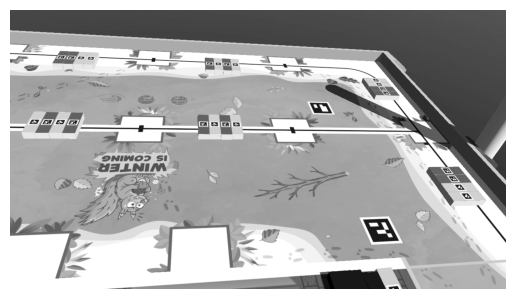

[ WARN:0@5104.060] global grfmt_png.cpp:695 read_chunk chunk data is too large


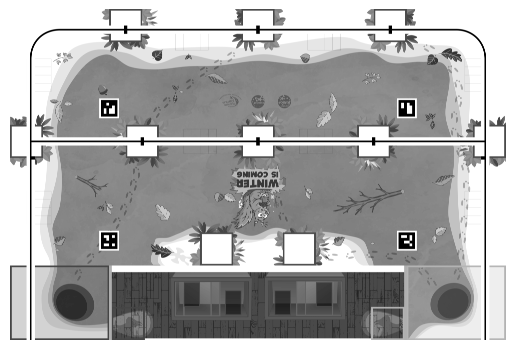

In [107]:
# Load an image using OpenCV
img_camera = cv2.imread('../../ressources/watchtower_view.png', 0) # Grayscale

# Display the image using matplotlib
plt.imshow(img_camera, cmap='gray')
plt.axis('off')  # Hide the axis
plt.show()

# Load an image using OpenCV
img_tapis = cv2.imread('../../ressources/table.png', 0) # Grayscale
img_tapis = cv2.rotate(img_tapis, cv2.ROTATE_180)
# Display the image using matplotlib
plt.imshow(img_tapis, cmap='gray')
plt.axis('off')  # Hide the axis
plt.show()

In [108]:
# 1. Initialisation de SIFT
sift = cv2.SIFT_create()

# 2. Détection des points clés
kp1, des1 = sift.detectAndCompute(img_tapis, None)
kp2, des2 = sift.detectAndCompute(img_camera, None)

# 3. Matching avec filtre de Lowe
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

# 4. Extraction et filtrage par Homographie (RANSAC)
src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

# M calcule le passage Tapis -> Caméra, mask identifie les bons points
M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

# On ne garde que les points validés par RANSAC (Inliers)
inlier_src = src_pts[mask.ravel() == 1].squeeze()
inlier_dst = dst_pts[mask.ravel() == 1].squeeze()

print(f"Nombre de points filtrés par RANSAC : {len(inlier_src)}")

Nombre de points filtrés par RANSAC : 258


In [109]:
# Dimensions de l'image tapis (en pixels)
h_tapis, w_tapis = img_tapis.shape[:2]

# Dimensions réelles
TABLE_L = 3.0 
TABLE_H = 2.0 

# Conversion Pixels -> Mètres (Origine au centre)
# On inverse le signe de X pour compenser l'inversion observée
x_m = -(inlier_src[:, 0] - w_tapis / 2) * (TABLE_L / w_tapis)

# On garde Y tel quel puisqu'il tombait juste (ou on le flip si besoin)
y_m = (inlier_src[:, 1] - h_tapis / 2) * (TABLE_H / h_tapis)

# Si ton Z réel doit être à 0.99, et que PnP te sort -0.99, 
# c'est souvent que le repère de rotation est inversé.
object_points = np.column_stack((x_m, y_m, np.zeros_like(x_m))).astype(np.float32)
image_points = inlier_dst.astype(np.float32)

print("--- DEBUG : Coordonnées Mondes (m) ---")
print(f"X min/max : {object_points[:,0].min():.3f} / {object_points[:,0].max():.3f}")
print(f"Y min/max : {object_points[:,1].min():.3f} / {object_points[:,1].max():.3f}")

--- DEBUG : Coordonnées Mondes (m) ---
X min/max : -1.252 / 0.305
Y min/max : -0.604 / 0.569


In [116]:
import transforms3d.quaternions as quat

# 1. SolvePnP
success, rvec_est, tvec_est = cv2.solvePnP(object_points, image_points, camera_matrix, dist_coeffs)

if success:
    # 2. Transformation pour obtenir la position Caméra dans le repère Monde
    R_est_opencv, _ = cv2.Rodrigues(rvec_est)
    # Dans le repère monde, la position est -R^T * t
    pos_est = -R_est_opencv.T @ tvec_est
    pos_est = pos_est.flatten()
    
    # 3. Calcul de l'erreur de distance
    pos_true = camera_pos_in_world 
    dist_error = np.linalg.norm(pos_true - pos_est)


    # 4. Transformation de la rotation sur le bon axe optique
    # OpenCV: Z-axis is optical axis (0, 0, 1)
    # Webots: X-axis is optical axis (1, 0, 0)
    # Rotation matrix to transform from OpenCV to Webots frame: 90° around Y
    R_opencv_to_webots = np.array([
        [0, -1, 0], # X_opencv = -Y_webots
        [0, 0, -1], # Y_opencv = -Z_webots
        [1, 0, 0]   # Z_opencv = X_webots
    ])

    # Apply transformation to the estimated rotation
    R_est_webots = R_est_opencv.T @ R_opencv_to_webots
    quat_est_webots = quat.mat2quat(R_est_webots)  # Returns (w, x, y, z)
    
    # Now use consistent axes for both --> X-axis for Webots convention
    z_axis_cam = np.array([1, 0, 0])

    forward_est = R_est_webots @ z_axis_cam # Direction de visée estimée
    forward_true = R_true @ z_axis_cam      # Direction de visée simu webots

    # Calcul de l'angle entre les deux vecteurs (Dot Product normalisé)
    cos_theta = np.dot(forward_est, forward_true) / (np.linalg.norm(forward_est) * np.linalg.norm(forward_true))
    angle_error_rad = np.arccos(np.clip(cos_theta, -1.0, 1.0))
    angle_error_deg = np.rad2deg(angle_error_rad)

#-----------
    y_axis = np.array([1, 0, 0])
    up_est = R_est_webots @ y_axis
    up_true = R_true @ y_axis
    cos_theta_up = np.dot(up_est, up_true) / (np.linalg.norm(up_est) * np.linalg.norm(up_true))
    angle_error_up = np.rad2deg(np.arccos(np.clip(cos_theta_up, -1.0, 1.0)))
    print(f"ERREUR (Axe X) : {angle_error_up:.4f} °")

    y_axis = np.array([0, 1, 0])
    up_est = R_est_webots @ y_axis
    up_true = R_true @ y_axis
    cos_theta_up = np.dot(up_est, up_true) / (np.linalg.norm(up_est) * np.linalg.norm(up_true))
    angle_error_up = np.rad2deg(np.arccos(np.clip(cos_theta_up, -1.0, 1.0)))
    print(f"ERREUR (Axe Y) : {angle_error_up:.4f} °")

    y_axis = np.array([0, 0, 1])
    up_est = R_est_webots @ y_axis
    up_true = R_true @ y_axis
    cos_theta_up = np.dot(up_est, up_true) / (np.linalg.norm(up_est) * np.linalg.norm(up_true))
    angle_error_up = np.rad2deg(np.arccos(np.clip(cos_theta_up, -1.0, 1.0)))
    print(f"ERREUR (Axe Z) : {angle_error_up:.4f} °")
#-----------
    # 5. Erreur de reprojection (pour valider la précision des pixels)
    projected_pts, _ = cv2.projectPoints(object_points, rvec_est, tvec_est, camera_matrix, dist_coeffs)
    repr_error = np.mean(np.linalg.norm(image_points - projected_pts.squeeze(), axis=1))

    print("=== RÉSULTATS DE LA CALIBRATION ===")
    print(f"Position Réelle   : {pos_true}")
    print(f"Position Estimée  : {pos_est}")
    print(f"------------------------------------------")
    print(f"Orientation Estimée (quat wxyz) : {np.array([quat_est_webots[0], quat_est_webots[1], quat_est_webots[2], quat_est_webots[3]])} OK")
    print(f"Orientation Réelle  (quat wxyz) : {np.array([camera_quat_in_world[3], camera_quat_in_world[0], camera_quat_in_world[1], camera_quat_in_world[2]])} OK")
    print(f"------------------------------------------")
    print(f"ERREUR TRANSLATION : {dist_error * 100:.2f} cm")
    print(f"ERREUR ORIENTATION  : {angle_error_deg:.4f} ° (Axe optique)")
    print(f"ERREUR REPROJECTION : {repr_error:.4f} pixels")
else:
    print("Erreur : SolvePnP n'a pas pu converger.")

ERREUR (Axe X) : 0.0371 °
ERREUR (Axe Y) : 0.0115 °
ERREUR (Axe Z) : 0.0387 °
=== RÉSULTATS DE LA CALIBRATION ===
Position Réelle   : [-0.225  1.12   0.99 ]
Position Estimée  : [-0.22523543  1.11958516  0.9904527 ]
------------------------------------------
Orientation Estimée (quat wxyz) : [ 0.60061898  0.21944006  0.26389528 -0.72212338] OK
Orientation Réelle  (quat wxyz) : [ 0.60069844  0.21927176  0.26362576 -0.72220686] OK
------------------------------------------
ERREUR TRANSLATION : 0.07 cm
ERREUR ORIENTATION  : 0.0371 ° (Axe optique)
ERREUR REPROJECTION : 0.6101 pixels


In [ ]:
# R_est_webots = R_est_opencv.T @ R_opencv_to_webots
# donc R_est_opencv = R_opencv_to_webots @ R_est_webots.T

print(f"R_est_webots = {R_est_webots}")
print(f"R_est_opencv calculated = {R_opencv_to_webots @ R_est_webots.T}")

print()

print(f"R_est_opencv = {R_est_opencv}")

R_est_webots = [[-1.82205806e-01  9.83260412e-01  7.54271853e-05]
 [-7.51623620e-01 -1.39232248e-01 -6.44729645e-01]
 [-6.33926634e-01 -1.17530177e-01  7.64410675e-01]]
R_est_opencv calculated = [[-9.83260412e-01  1.39232248e-01  1.17530177e-01]
 [-7.54271853e-05  6.44729645e-01 -7.64410675e-01]
 [-1.82205806e-01 -7.51623620e-01 -6.33926634e-01]]

R_est_opencv = [[-9.83260412e-01  1.39232248e-01  1.17530177e-01]
 [-7.54271853e-05  6.44729645e-01 -7.64410675e-01]
 [-1.82205806e-01 -7.51623620e-01 -6.33926634e-01]]


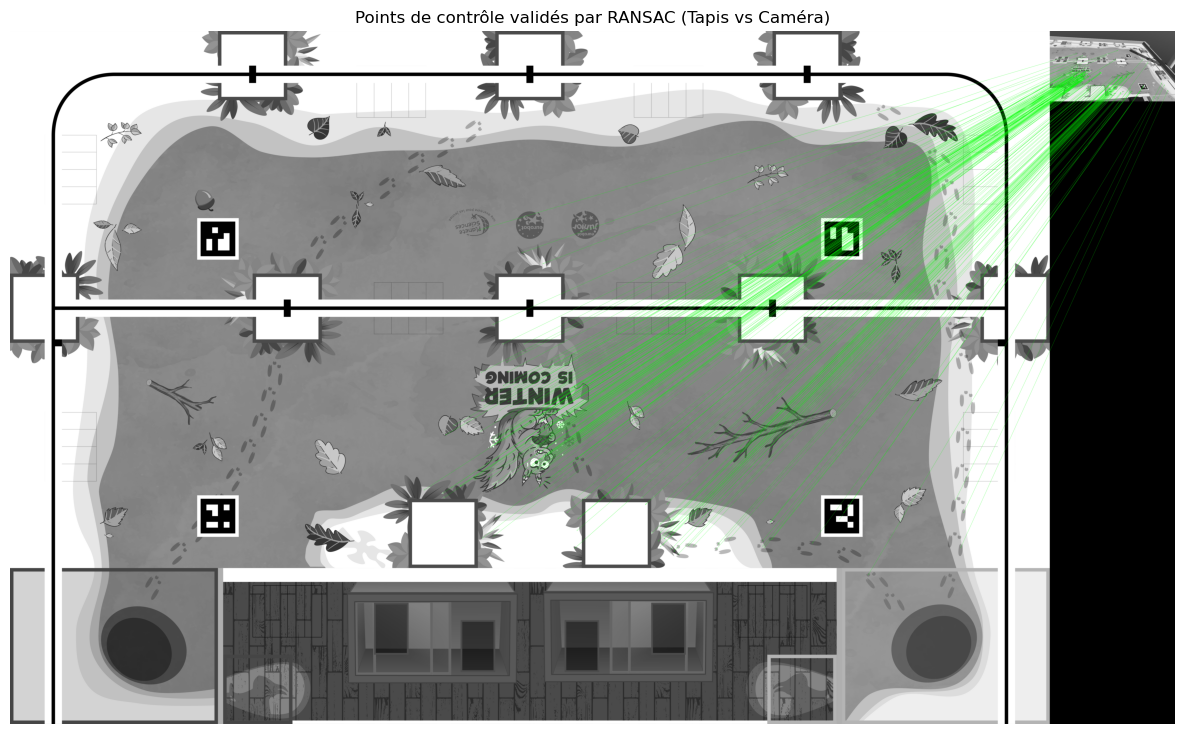

In [112]:
# Préparation du masque pour n'afficher que les inliers de RANSAC
matches_mask = mask.ravel().tolist()

draw_params = dict(matchColor = (0, 255, 0), # Lignes vertes
                   singlePointColor = None,
                   matchesMask = matches_mask,
                   flags = 2)

img_matches = cv2.drawMatches(img_tapis, kp1, img_camera, kp2, good_matches, None, **draw_params)

plt.figure(figsize=(18, 9))
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title("Points de contrôle validés par RANSAC (Tapis vs Caméra)")
plt.axis('off')
plt.show()